# L10b Lab: Multiplicative Weights for Competing Operating Policies

> **Learning objectives**
>
> - Convert expert losses into a probability distribution.
> - Apply the exponential multiplicative update.
> - Track cumulative learner loss and regret.
> - Interpret the learning-rate tradeoff.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week10Core` module from [`../src/Week10Core.jl`](../src/Week10Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


The setup cell completed, so the environment and this lab's local source are loaded. The cell below builds the loss stream for three competing operating policies over `rounds::Int64` rounds in `losses::Matrix{Float64}`, one column per expert, then runs the learner. The outcome is `result::NamedTuple`, carrying `probabilities::Matrix{Float64}`, `learner_total::Float64`, `expert_totals::Vector{Float64}`, `regret::Float64`, and `final_weights::Vector{Float64}`, compared in `summary::DataFrame`.


In [2]:
rounds = 60
losses = hcat(
    [round % 7 in (1, 2) ? 0.9 : 0.2 for round in 1:rounds],
    [round <= 30 ? 0.25 : 0.65 for round in 1:rounds],
    [0.45 + 0.10sin(round) for round in 1:rounds],
)
result = weighted_majority(losses; eta = 0.7)

summary = DataFrame(expert = ["reactive", "conservative", "steady"],
    cumulative_loss = result.expert_totals, final_weight = result.final_weights)
pretty_table(summary)
(learner_loss = result.learner_total, regret = result.regret)


┌──────────────┬─────────────────┬──────────────┐
│       expert │ cumulative_loss │ final_weight │
│       String │         Float64 │      Float64 │
├──────────────┼─────────────────┼──────────────┤
│     reactive │            24.6 │   3.32238e-8 │
│ conservative │            27.0 │   6.19205e-9 │
│       steady │         27.1635 │    5.5226e-9 │
└──────────────┴─────────────────┴──────────────┘


(learner_loss = 26.191901446538875, regret = 1.5919014465388734)

In [3]:
@test all(abs.(sum(result.probabilities; dims = 2) .- 1.0) .< 1e-12)
@test result.regret >= 0
@test argmax(result.final_weights) == argmin(result.expert_totals)
:multiplicative_weights_verified


:multiplicative_weights_verified

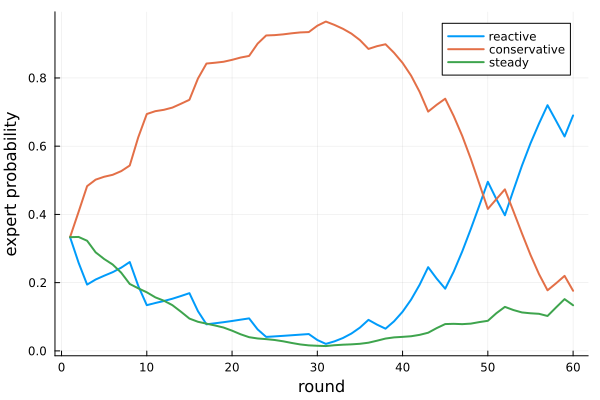

In [4]:
plot(result.probabilities[:, 1]; lw = 2, label = "reactive", xlabel = "round", ylabel = "expert probability")
plot!(result.probabilities[:, 2]; lw = 2, label = "conservative")
plot!(result.probabilities[:, 3]; lw = 2, label = "steady")


## Summary

Multiplicative weights does not commit permanently to one expert; it continuously reallocates probability according to observed losses. Regret is always relative to the chosen comparator class.
